<a href="https://colab.research.google.com/github/osamoilova95-afk/mate-academy-python-da/blob/main/%D0%97%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F_Python_for_DA_Module_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data overview. Розуміння даних та їх змісту**

In [ ]:
import zipfile
import pandas as pd

# Завантажуємо оригінальні дані з архіву
zip_path = '/content/dataset (1).zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    events_df = pd.read_csv(z.open('13. Final project/events.csv'))
    products_df = pd.read_csv(z.open('13. Final project/products.csv'))
    countries_df = pd.read_csv(z.open('13. Final project/countries.csv'))

print("--- EVENTS INFO ---")
events_df.info()
print("\n--- PRODUCTS INFO ---")
products_df.info()
print("\n--- COUNTRIES INFO ---")
countries_df.info()


--- EVENTS INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB

--- PRODUCTS INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null

# **Data cleaning. Робота із пропущеними даними, некоректними даними, аномаліями**

In [ ]:
# 1. Оцінка долі пропущених значень у відсотках (%)
def check_missing(df, name):
    print(f"\n Пропуски для таблиці {name}:")
    missing_count = df.isnull().sum()
    missing_pct = (missing_count / len(df)) * 100
    report = pd.DataFrame({'Кількість пропусків': missing_count, 'Доля пропусків (%)': missing_pct.round(2)})
    print(report[report['Кількість пропусків'] > 0] if missing_count.sum() > 0 else "Пропусків не знайдено")

check_missing(events_df, "EVENTS")
check_missing(products_df, "PRODUCTS")
check_missing(countries_df, "COUNTRIES")

# 2. Очищення даних та приведення типів безпосередньо в окремих таблицях
events_df['Order Date'] = pd.to_datetime(events_df['Order Date'])
events_df['Ship Date'] = pd.to_datetime(events_df['Ship Date'])

# Виправляємо аномалію регістру "online" / "Online" за зауваженням ментора
if 'Sales Channel' in events_df.columns:
    events_df['Sales Channel'] = events_df['Sales Channel'].astype(str).str.capitalize()

# Заповнюємо чисельні пропуски медіаною
events_df['Units Sold'] = events_df['Units Sold'].fillna(events_df['Units Sold'].median()).astype('int64')

# Перевірка на повні дублікати
print(f"\nПовних дублікатів у EVENTS: {events_df.duplicated().sum()}")



 Пропуски для таблиці EVENTS:
              Кількість пропусків  Доля пропусків (%)
Country Code                   82                6.17

 Пропуски для таблиці PRODUCTS:
Пропусків не знайдено

 Пропуски для таблиці COUNTRIES:
            Кількість пропусків  Доля пропусків (%)
alpha-2                       1                 0.4
region                        1                 0.4
sub-region                    1                 0.4

Повних дублікатів у EVENTS: 0


# **Data analysis and visualization. Аналіз та візуалізація даних**

In [ ]:
# Приводимо назви до нижнього регістру перед merge, щоб уникнути помилок з регістром Item_type
events_df.columns = events_df.columns.str.lower()
products_df.columns = products_df.columns.str.lower()
countries_df.columns = countries_df.columns.str.lower()

# З'єднання таблиць (how='left' гарантує збереження всіх транзакцій)
merged_df = pd.merge(events_df, products_df, left_on='product id', right_on='id', how='left').drop(columns=['id'])
final_df = pd.merge(merged_df, countries_df, left_on='country code', right_on='alpha-3', how='left').drop(columns=['alpha-3'])

# Перейменування колонок в єдиний зрозумілий формат
rename_dict = {
    'order id': 'order_id', 'order date': 'order_date', 'ship date': 'ship_date',
    'order priority': 'order_priority', 'country code': 'country_code', 'product id': 'product_id',
    'sales channel': 'sales_channel', 'units sold': 'units_sold', 'unit price': 'unit_price',
    'unit cost': 'unit_cost', 'item_type': 'product_category', 'name': 'country_name',
    'region': 'region', 'sub-region': 'sub_region'
}
final_df = final_df.rename(columns=rename_dict)

# Явне заповнення Unknown для текстових колонок (без крихких формул з split)
final_df['country_code'] = final_df['country_code'].fillna('Unknown')
final_df['product_category'] = final_df['product_category'].fillna('Unknown Category')
final_df['country_name'] = final_df['country_name'].fillna('Unknown Country')
final_df['region'] = final_df['region'].fillna('Unknown Region')
final_df['sub_region'] = final_df['sub_region'].fillna('Unknown Sub-Region')

# Розрахунок нових метрик прибутку та доставки
final_df['revenue'] = final_df['units_sold'] * final_df['unit_price']
final_df['total_cost'] = final_df['units_sold'] * final_df['unit_cost']
final_df['profit'] = final_df['revenue'] - final_df['total_cost']
final_df['delivery_days'] = (final_df['ship_date'] - final_df['order_date']).dt.days

print(f" Таблиці успішно об'єднано. Розмір фінального датафрейму: {final_df.shape}")


 Таблиці успішно об'єднано. Розмір фінального датафрейму: (1330, 19)


In [ ]:
print(" АКТУАЛЬНІ КЛЮЧОВІ МЕТРИКИ (KPI) ")
total_orders = final_df['order_id'].nunique()
total_revenue = final_df['revenue'].sum()
total_cost = final_df['total_cost'].sum()
total_profit = final_df['profit'].sum()
margin = (total_profit / total_revenue) * 100
total_units = final_df['units_sold'].sum()
aov = total_revenue / total_orders

#  ВИПРАВЛЕННЯ: Рахуємо унікальні країни, виключаючи маркер 'Unknown Country'
real_countries_count = final_df[final_df['country_name'] != 'Unknown Country']['country_name'].nunique()

print(f"* Загальна кількість замовлень: {total_orders:,} транзакцій")
print(f"* Загальний дохід (Total Revenue): ${total_revenue:,.2f} USD")
print(f"* Загальні витрати (Total Cost): ${total_cost:,.2f} USD")
print(f"* Загальний прибуток (Total Profit): ${total_profit:,.2f} USD")
print(f"* Середня маржинальність бізнесу: {margin:.2f}%")
print(f"* Географічне охоплення: {real_countries_count} унікальних країн")
print(f"* Загальна кількість проданих одиниць: {total_units:,} штук")
print(f"* Середній чек замовлення (AOV): ${aov:,.2f} USD")
print("=================================================================\n")


 АКТУАЛЬНІ КЛЮЧОВІ МЕТРИКИ (KPI) 
* Загальна кількість замовлень: 1,330 транзакцій
* Загальний дохід (Total Revenue): $1,704,628,370.65 USD
* Загальні витрати (Total Cost): $1,202,785,737.53 USD
* Загальний прибуток (Total Profit): $501,842,633.12 USD
* Середня маржинальність бізнесу: 29.44%
* Географічне охоплення: 45 унікальних країн
* Загальна кількість проданих одиниць: 6,586,448 штук
* Середній чек замовлення (AOV): $1,281,675.47 USD



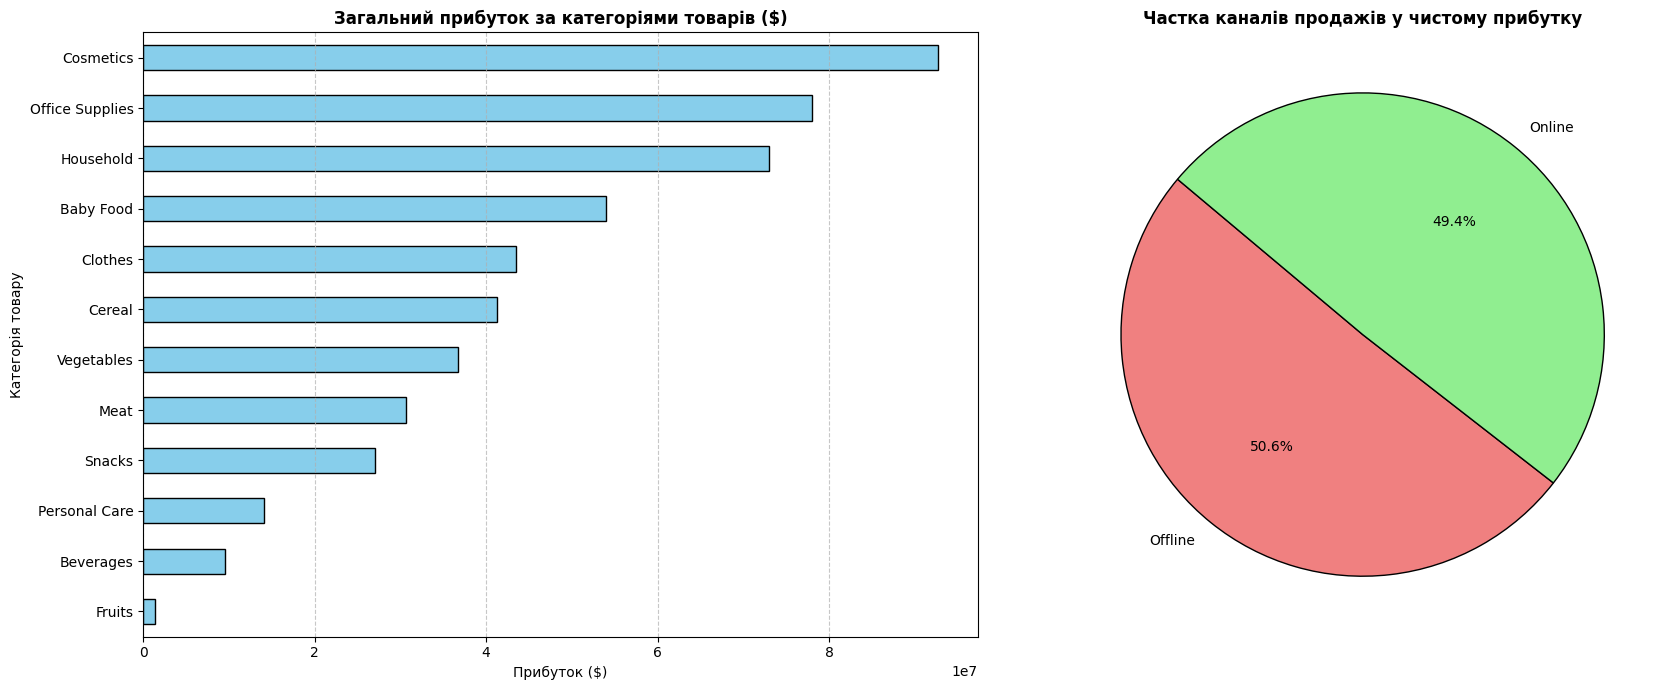

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

#  ВИПРАВЛЕННЯ NameError: явно створюємо cat_analysis
cat_analysis = final_df.groupby('product_category')['profit'].sum().sort_values(ascending=True)

# Графік за категоріями
cat_analysis.plot(kind='barh', color='skyblue', edgecolor='black', ax=ax1)
ax1.set_title('Загальний прибуток за категоріями товарів ($)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Прибуток ($)')
ax1.set_ylabel('Категорія товару')
ax1.grid(axis='x', linestyle='--', alpha=0.7)

# Графік за каналами (Тут буде рівно 2 чистих сектори)
sales_channel_profit = final_df.groupby('sales_channel')['profit'].sum()
ax2.pie(sales_channel_profit, labels=sales_channel_profit.index, autopct='%1.1f%%',
        colors=['lightcoral', 'lightgreen'], startangle=140, wedgeprops={'edgecolor': 'black'})
ax2.set_title('Частка каналів продажів у чистому прибутку', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


================ ТОП-10 НАЙПРИБУТКОВІШИХ КРАЇН ================
 1. Andorra: $15,410,036.63 USD
 2. Ukraine: $14,804,925.74 USD
 3. Malta: $14,610,127.88 USD
 4. San Marino: $13,792,992.81 USD
 5. Hungary: $13,786,231.03 USD
 6. Macedonia: $13,684,099.95 USD
 7. Czech Republic: $13,635,593.78 USD
 8. Russia: $13,267,682.64 USD
 9. Bosnia and Herzegovina: $13,257,602.77 USD
 10. Greece: $12,324,450.13 USD



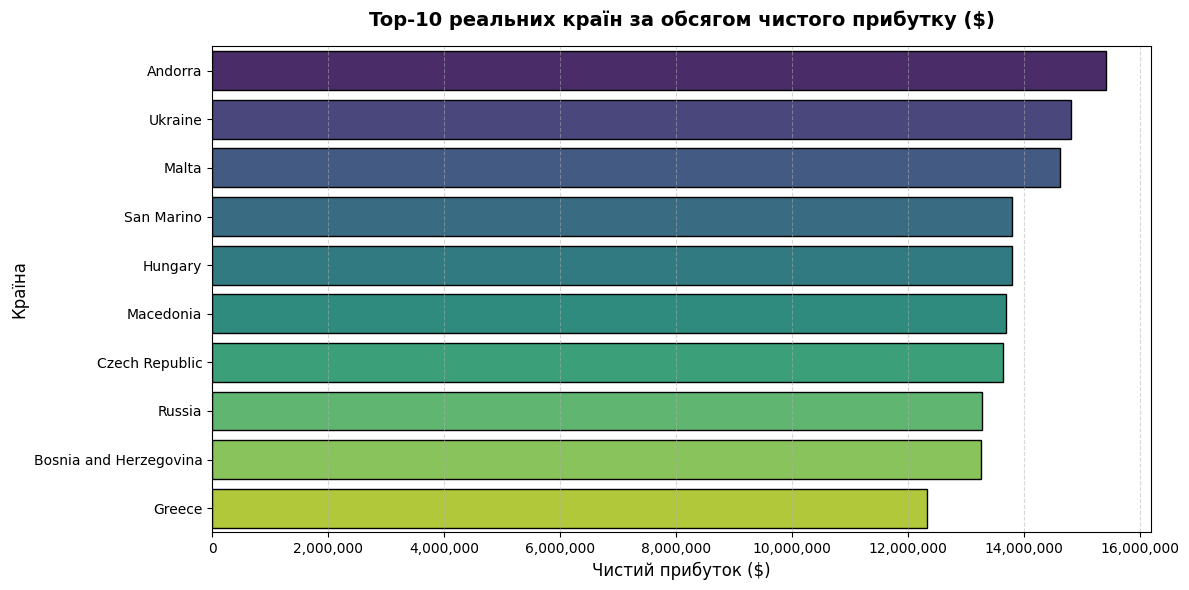

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Фільтруємо дані, виключаючи технічне значення 'Unknown Country'
filtered_countries = final_df[final_df['country_name'] != 'Unknown Country']

# 2. Групуємо по країнах і беремо Топ-10 найприбутковіших
country_profit = filtered_countries.groupby('country_name')['profit'].sum().sort_values(ascending=False).head(10)

print("================ ТОП-10 НАЙПРИБУТКОВІШИХ КРАЇН ================")
for rank, (country, prof) in enumerate(country_profit.items(), 1):
    print(f" {rank}. {country}: ${prof:,.2f} USD")
print("===============================================================\n")

# 3. Візуалізація чистого прибутку по реальних країнах
plt.figure(figsize=(12, 6))

# Будуємо красивий горизонтальний графік
sns.barplot(
    x=country_profit.values,
    y=country_profit.index,
    hue=country_profit.index,
    palette='viridis',
    edgecolor='black',
    legend=False
)

# Оформлення графіка
plt.title('Top-10 реальних країн за обсягом чистого прибутку ($)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Чистий прибуток ($)', fontsize=12)
plt.ylabel('Країна', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Форматуємо шкалу X, розділяючи тисячі комами
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()


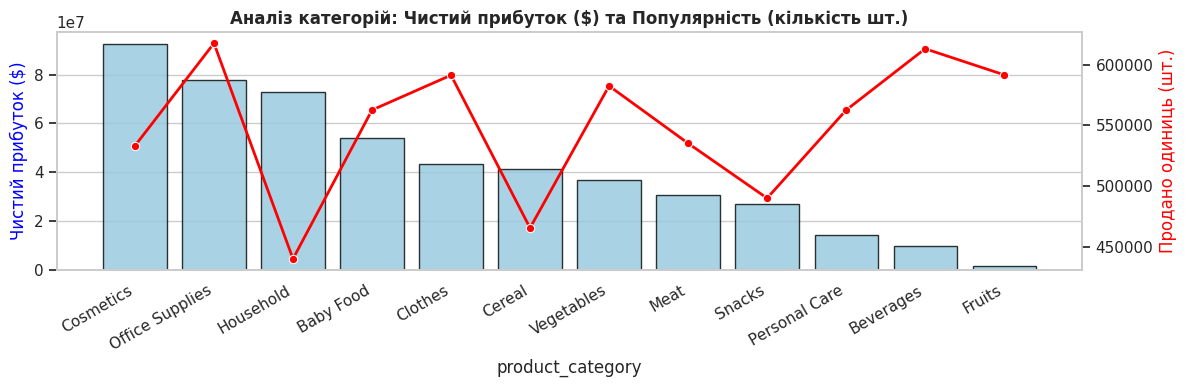


================== ГЕОГРАФІЧНИЙ АНАЛІЗ ==================
Топ-5 реальних країн за прибутком:
 - Andorra              : $15,410,036.63 USD
 - Ukraine              : $14,804,925.74 USD
 - Malta                : $14,610,127.88 USD
 - San Marino           : $13,792,992.81 USD
 - Hungary              : $13,786,231.03 USD


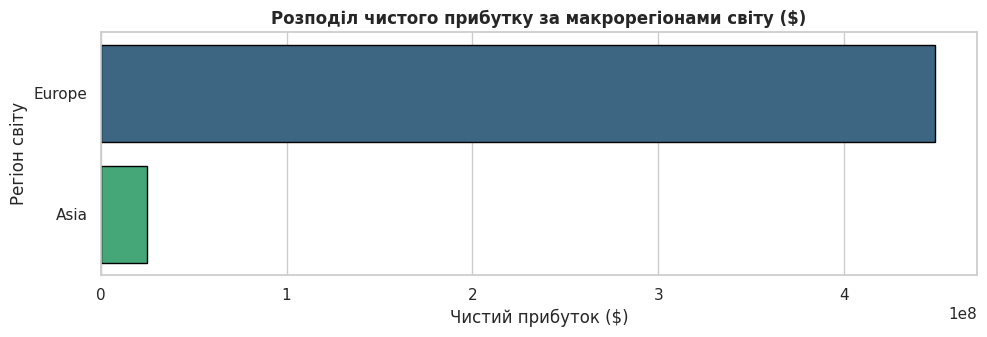


================== АНАЛІЗ КАНАЛІВ ЗБУТУ ==================
Канал: Offline | Дохід: $874,259,586.32 | Витрати: $620,384,893.39 | Прибуток: $253,874,692.93
Канал: Online  | Дохід: $830,368,784.33 | Витрати: $582,400,844.14 | Прибуток: $247,967,940.19


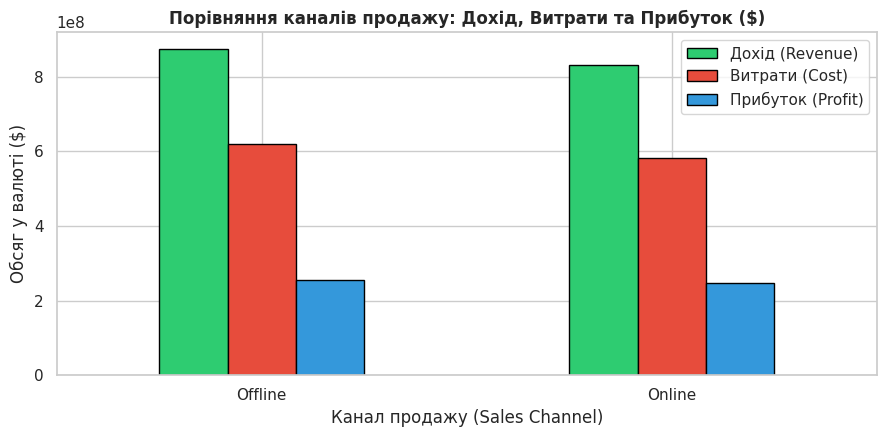

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# НАЛАШТУВАННЯ: Виправляємо регістр у каналах продажів (Усуваємо аномалію 'Online' vs 'online')
final_df['sales_channel'] = final_df['sales_channel'].astype(str).str.strip().str.capitalize()

# Налаштування стилю для чіткості графіків
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

# --- 1. АНАЛІЗ У РОЗРІЗІ КАТЕГОРІЙ ТОВАРІВ ---
#  ВИПРАВЛЕННЯ NameError: Спочатку рахуємо cat_analysis, групуючи за новою назвою product_category
cat_analysis = final_df.groupby('product_category').agg(
    profit=('profit', 'sum'),
    units_sold=('units_sold', 'sum')
).sort_values(by='profit', ascending=False)

# Візуалізація 1: Прибуток та Популярність товарів
fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

# Побудова графіків
sns.barplot(x=cat_analysis.index, y=cat_analysis['profit'], ax=ax1, color='skyblue', edgecolor='black', alpha=0.8)
sns.lineplot(x=cat_analysis.index, y=cat_analysis['units_sold'], ax=ax2, color='red', marker='o', linewidth=2, sort=False)

ax1.set_title('Аналіз категорій: Чистий прибуток ($) та Популярність (кількість шт.)', fontsize=12, fontweight='bold')

# Фіксуємо позиції ділень перед зміною їх тексту
ax1.set_xticks(range(len(cat_analysis.index)))
ax1.set_xticklabels(cat_analysis.index, rotation=30, ha='right')

ax1.set_ylabel('Чистий прибуток ($)', color='blue')
ax2.set_ylabel('Продано одиниць (шт.)', color='red')
ax2.grid(False)
plt.tight_layout()
plt.show()


# --- 2. ГЕОГРАФІЧНИЙ АНАЛІЗ (РЕГІОНИ ТА ТОП КРАЇН) ---
region_analysis = final_df.groupby('region')['profit'].sum().sort_values(ascending=False)
if 'Unknown Region' in region_analysis.index:
    region_analysis = region_analysis.drop('Unknown Region')

# Фільтруємо технічні Unknown для пошуку топ країн
filtered_countries = final_df[final_df['country_name'] != 'Unknown Country']
top_countries = filtered_countries.groupby('country_name')['profit'].sum().sort_values(ascending=False).head(5)

print("\n================== ГЕОГРАФІЧНИЙ АНАЛІЗ ==================")
print("Топ-5 реальних країн за прибутком:")
for country, prof in top_countries.items():
    print(f" - {country:<20} : ${prof:,.2f} USD")

# Візуалізація 2: Прибуток за регіонами
plt.figure(figsize=(10, 3.5))
sns.barplot(
    x=region_analysis.values,
    y=region_analysis.index,
    hue=region_analysis.index,
    palette='viridis',
    edgecolor='black',
    legend=False
)
plt.title('Розподіл чистого прибутку за макрорегіонами світу ($)', fontsize=12, fontweight='bold')
plt.xlabel('Чистий прибуток ($)')
plt.ylabel('Регіон світу')
plt.tight_layout()
plt.show()


# --- 3. ІСПРАВЛЕНИЙ АНАЛІЗ КАНАЛІВ ПРОДАЖУ (ONLINE VS OFFLINE) ---
channel_analysis = final_df.groupby('sales_channel').agg(
    revenue=('revenue', 'sum'),
    total_cost=('total_cost', 'sum'),
    profit=('profit', 'sum')
).sort_values(by='profit', ascending=False)

print("\n================== АНАЛІЗ КАНАЛІВ ЗБУТУ ==================")
for ch, row in channel_analysis.iterrows():
    print(f"Канал: {ch:<7} | Дохід: ${row['revenue']:<14,.2f} | Витрати: ${row['total_cost']:<14,.2f} | Прибуток: ${row['profit']:,.2f}")

# Візуалізація 3: Порівняння структури доходів та витрат по каналах
channel_analysis[['revenue', 'total_cost', 'profit']].plot(kind='bar', figsize=(9, 4.5), color=['#2ecc71', '#e74c3c', '#3498db'], edgecolor='black')
plt.title('Порівняння каналів продажу: Дохід, Витрати та Прибуток ($)', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.xlabel('Канал продажу (Sales Channel)')
plt.ylabel('Обсяг у валюті ($)')
plt.legend(['Дохід (Revenue)', 'Витрати (Cost)', 'Прибуток (Profit)'])
plt.tight_layout()
plt.show()


# АНАЛІЗ ІНТЕРВАЛУ ЧАСУ МІЖ ЗАМОВЛЕННЯМ ТА ВІДВАНТАЖЕННЯМ

================== АНАЛІЗ ШВИДКОСТІ ДОСТАВКИ ==================
 Середній час відвантаження по компанії: 24.8 днів
 Мінімальний термін відвантаження:       0 днів
 Максимальний термін відвантаження:       50 днів


/tmp/ipykernel_3734/1483732573.py:61: UserWarning: Glyph 25079 (\N{CJK UNIFIED IDEOGRAPH-61F7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25079 (\N{CJK UNIFIED IDEOGRAPH-61F7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


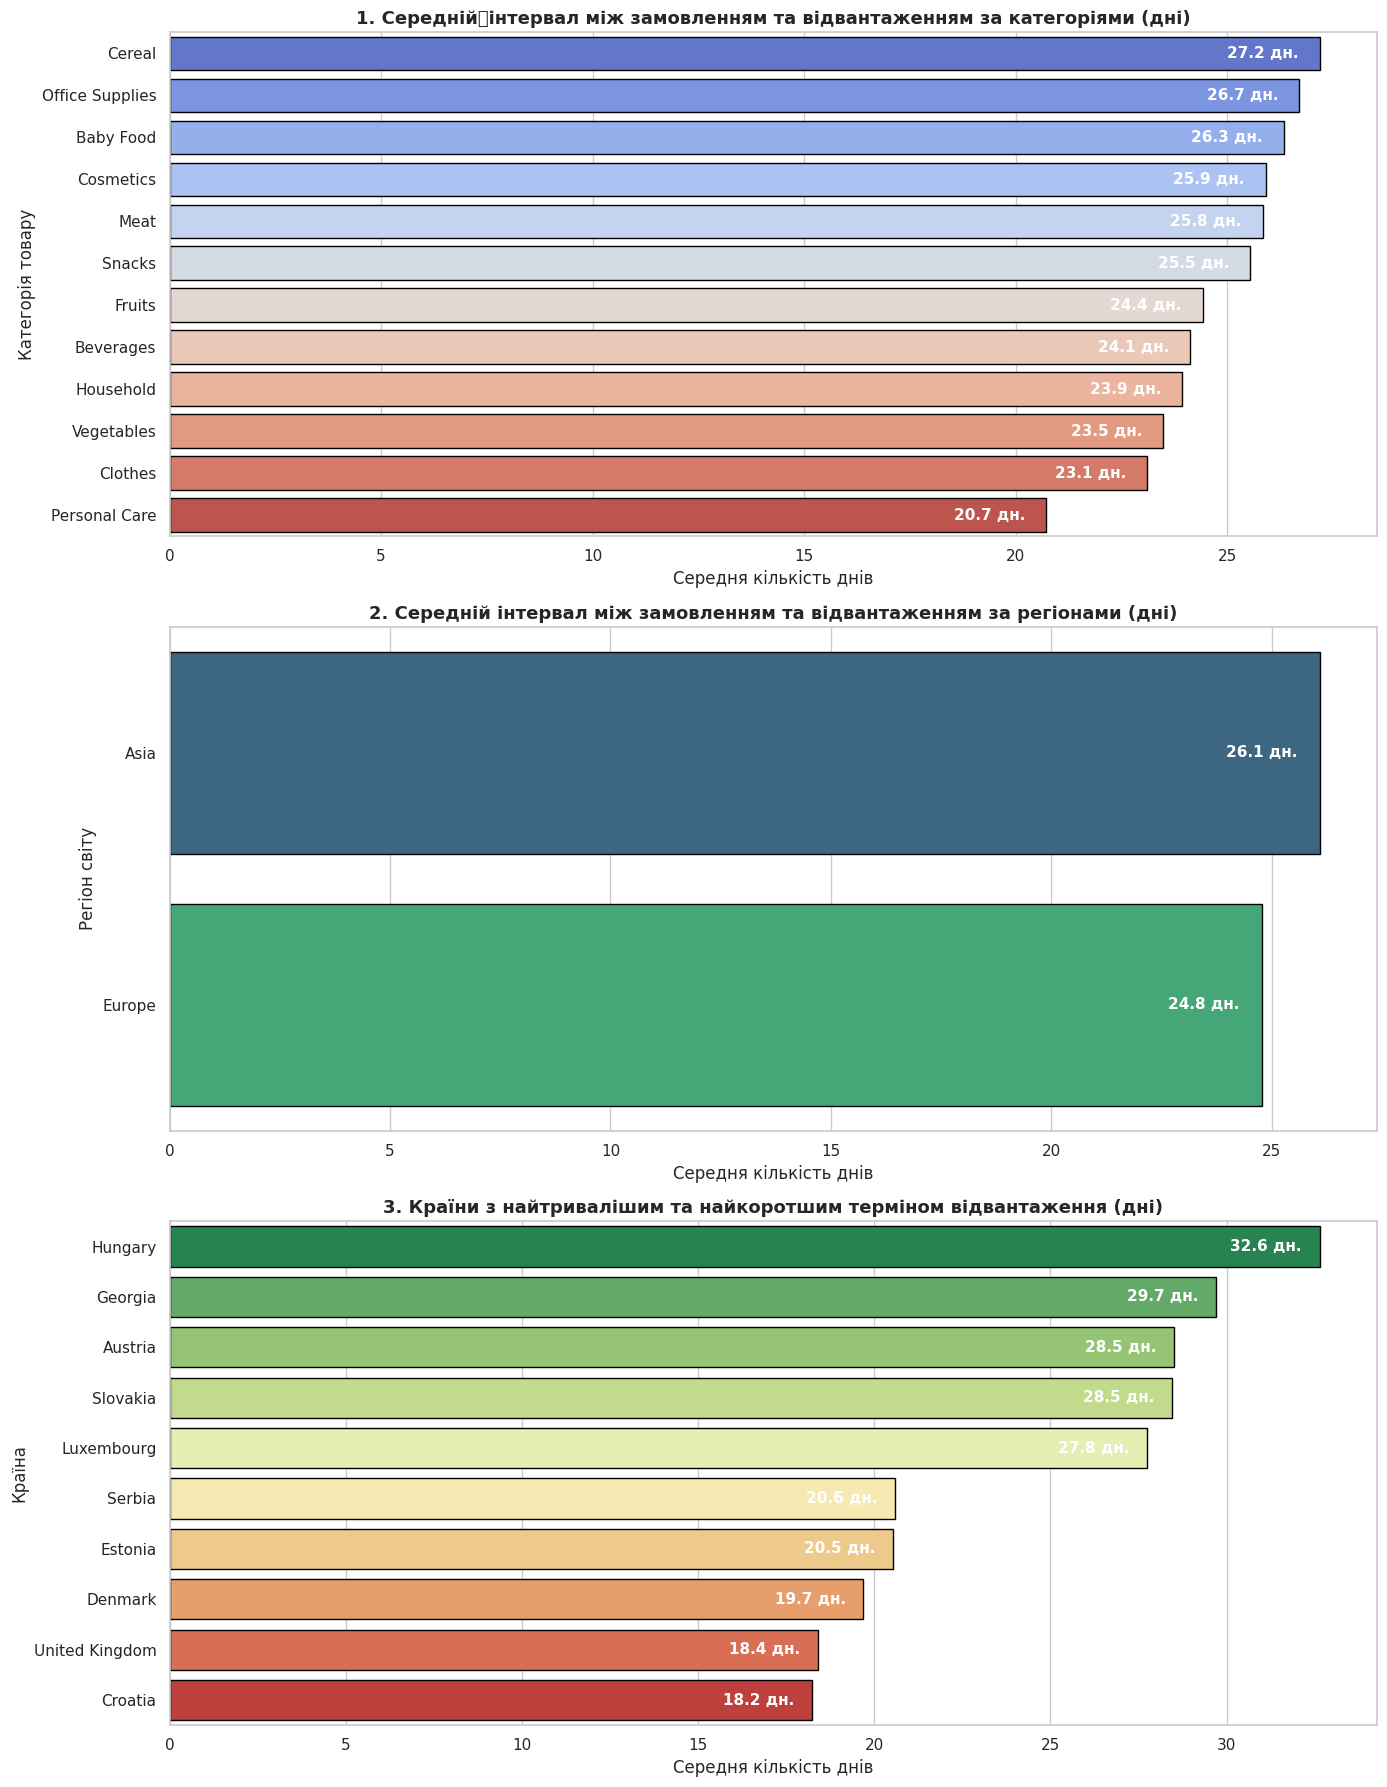

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Налаштування стилю графіків
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

print("================== АНАЛІЗ ШВИДКОСТІ ДОСТАВКИ ==================")
#  ВИПРАВЛЕННЯ: Використовуємо правильний датафрейм final_df
avg_delivery_global = final_df['delivery_days'].mean()
min_delivery = final_df['delivery_days'].min()
max_delivery = final_df['delivery_days'].max()

print(f" Середній час відвантаження по компанії: {avg_delivery_global:.1f} днів")
print(f" Мінімальний термін відвантаження:       {min_delivery} днів")
print(f" Максимальний термін відвантаження:       {max_delivery} днів")

# --- 1. РОЗРАХУНОК ДЛЯ КАТЕГОРІЙ, РЕГІОНІВ ТА КРАЇН ---
cat_delivery = final_df.groupby('product_category')['delivery_days'].mean().sort_values(ascending=False)
region_delivery = final_df.groupby('region')['delivery_days'].mean().sort_values(ascending=False)
if 'Unknown Region' in region_delivery.index:
    region_delivery = region_delivery.drop('Unknown Region')

# Топ-5 країн з найповільнішою доставкою та Топ-5 з найшвидшою
country_delivery = final_df.groupby('country_name')['delivery_days'].mean().sort_values(ascending=False)
if 'Unknown Country' in country_delivery.index:
    country_delivery = country_delivery.drop('Unknown Country')

# --- 2. ПОБУДОВА ВІЗУАЛІЗАЦІЙ ---
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

# Графік 1: Середній термін доставки за категоріями товарів
sns.barplot(x=cat_delivery.values, y=cat_delivery.index, hue=cat_delivery.index, palette='coolwarm', edgecolor='black', ax=axes[0], legend=False)
axes[0].set_title('1. Середній懷інтервал між замовленням та відвантаженням за категоріями (дні)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Середня кількість днів')
axes[0].set_ylabel('Категорія товару')
for bar in axes[0].patches:
    if bar.get_width() > 0: # Перевірка, щоб уникнути помилок порожніх стовпчиків
        axes[0].text(bar.get_width() - 0.5, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.1f} дн.', va='center', ha='right', color='white', fontweight='bold')

# Графік 2: Середній термін доставки за макрорегіонами
sns.barplot(x=region_delivery.values, y=region_delivery.index, hue=region_delivery.index, palette='viridis', edgecolor='black', ax=axes[1], legend=False)
axes[1].set_title('2. Середній інтервал між замовленням та відвантаженням за регіонами (дні)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Середня кількість днів')
axes[1].set_ylabel('Регіон світу')
for bar in axes[1].patches:
    if bar.get_width() > 0:
        axes[1].text(bar.get_width() - 0.5, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.1f} дн.', va='center', ha='right', color='white', fontweight='bold')

# Графік 3: Країни-екстремуми (5 найшвидших та 5 найповільніших)
extreme_countries = pd.concat([country_delivery.head(5), country_delivery.tail(5)])
sns.barplot(x=extreme_countries.values, y=extreme_countries.index, hue=extreme_countries.index, palette='RdYlGn_r', edgecolor='black', ax=axes[2], legend=False)
axes[2].set_title('3. Країни з найтривалішим та найкоротшим терміном відвантаження (дні)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Середня кількість днів')
axes[2].set_ylabel('Країна')
for bar in axes[2].patches:
    if bar.get_width() > 0:
        axes[2].text(bar.get_width() - 0.5, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.1f} дн.', va='center', ha='right', color='white', fontweight='bold')

plt.tight_layout()
plt.show()


# Кореляційний аналіз

================== АНАЛІЗ ЗАЛЕЖНОСТІ ПРИБУТКУ ВІД ЛОГІСТИКИ ==================
📉 Коефіцієнт кореляції Пірсона: 0.0607


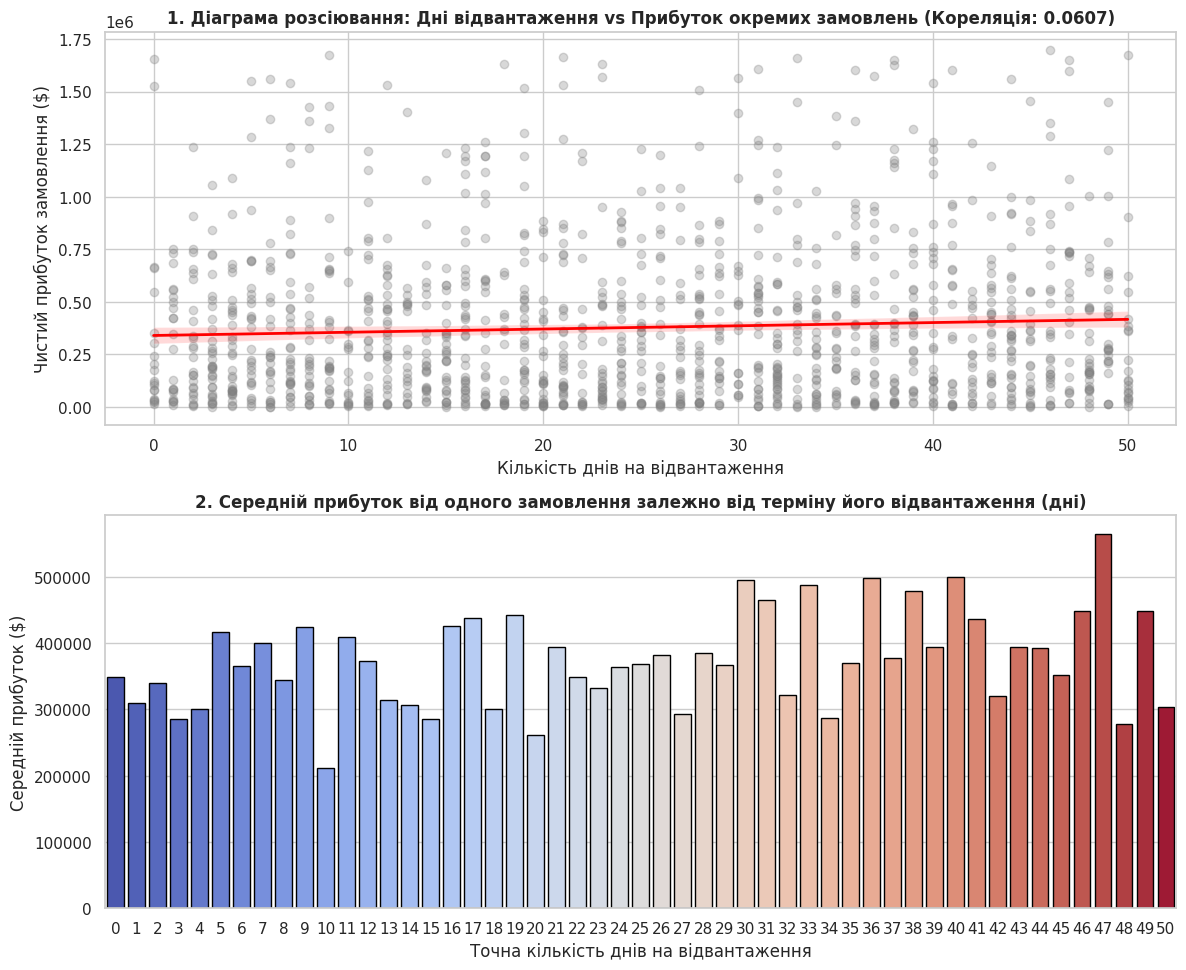

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Налаштування стилю графіків
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

# --- 1. РОЗРАХУНОК КОРЕЛЯЦІЇ ТА АГРЕГУВАННЯ ---
#  ВИПРАВЛЕННЯ: Використовуємо правильний датафрейм final_df
correlation = final_df['delivery_days'].corr(final_df['profit'])

print("================== АНАЛІЗ ЗАЛЕЖНОСТІ ПРИБУТКУ ВІД ЛОГІСТИКИ ==================")
print(f"📉 Коефіцієнт кореляції Пірсона: {correlation:.4f}")

# Агрегуємо дані за кількістю днів, щоб побачити середній прибуток на кожен конкретний термін обробки
delivery_profit_agg = final_df.groupby('delivery_days')['profit'].agg(['mean', 'sum', 'count']).reset_index()

# --- 2. ПОБУДОВА ВІЗУАЛІЗАЦІЙ ---
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Графік 1: Scatter plot (діаграма розсіювання) з лінією тренду для всіх транзакцій
sns.regplot(
    data=final_df,
    x='delivery_days',
    y='profit',
    ax=axes[0],
    scatter_kws={'alpha':0.3, 'color': 'gray'},
    line_kws={'color': 'red', 'linewidth': 2}
)
axes[0].set_title(f'1. Діаграма розсіювання: Дні відвантаження vs Прибуток окремих замовлень (Кореляція: {correlation:.4f})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Кількість днів на відвантаження')
axes[0].set_ylabel('Чистий прибуток замовлення ($)')

# Графік 2: Барплот середнього прибутку залежно від точної кількості днів відвантаження
sns.barplot(
    data=delivery_profit_agg,
    x='delivery_days',
    y='mean',
    ax=axes[1],
    hue='delivery_days',
    palette='coolwarm',
    edgecolor='black',
    legend=False
)
axes[1].set_title('2. Середній прибуток від одного замовлення залежно від терміну його відвантаження (дні)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Точна кількість днів на відвантаження')
axes[1].set_ylabel('Середній прибуток ($)')

plt.tight_layout()
plt.show()


# АНАЛІЗ ДИНАМІКИ ПРОДАЖІВ ТА ОСНОВНИХ ТЕНДЕНЦІЙ У ЧАСІ

================== АНАЛІЗ ДИНАМІКИ ПРОДАЖІВ У ЧАСІ ==================


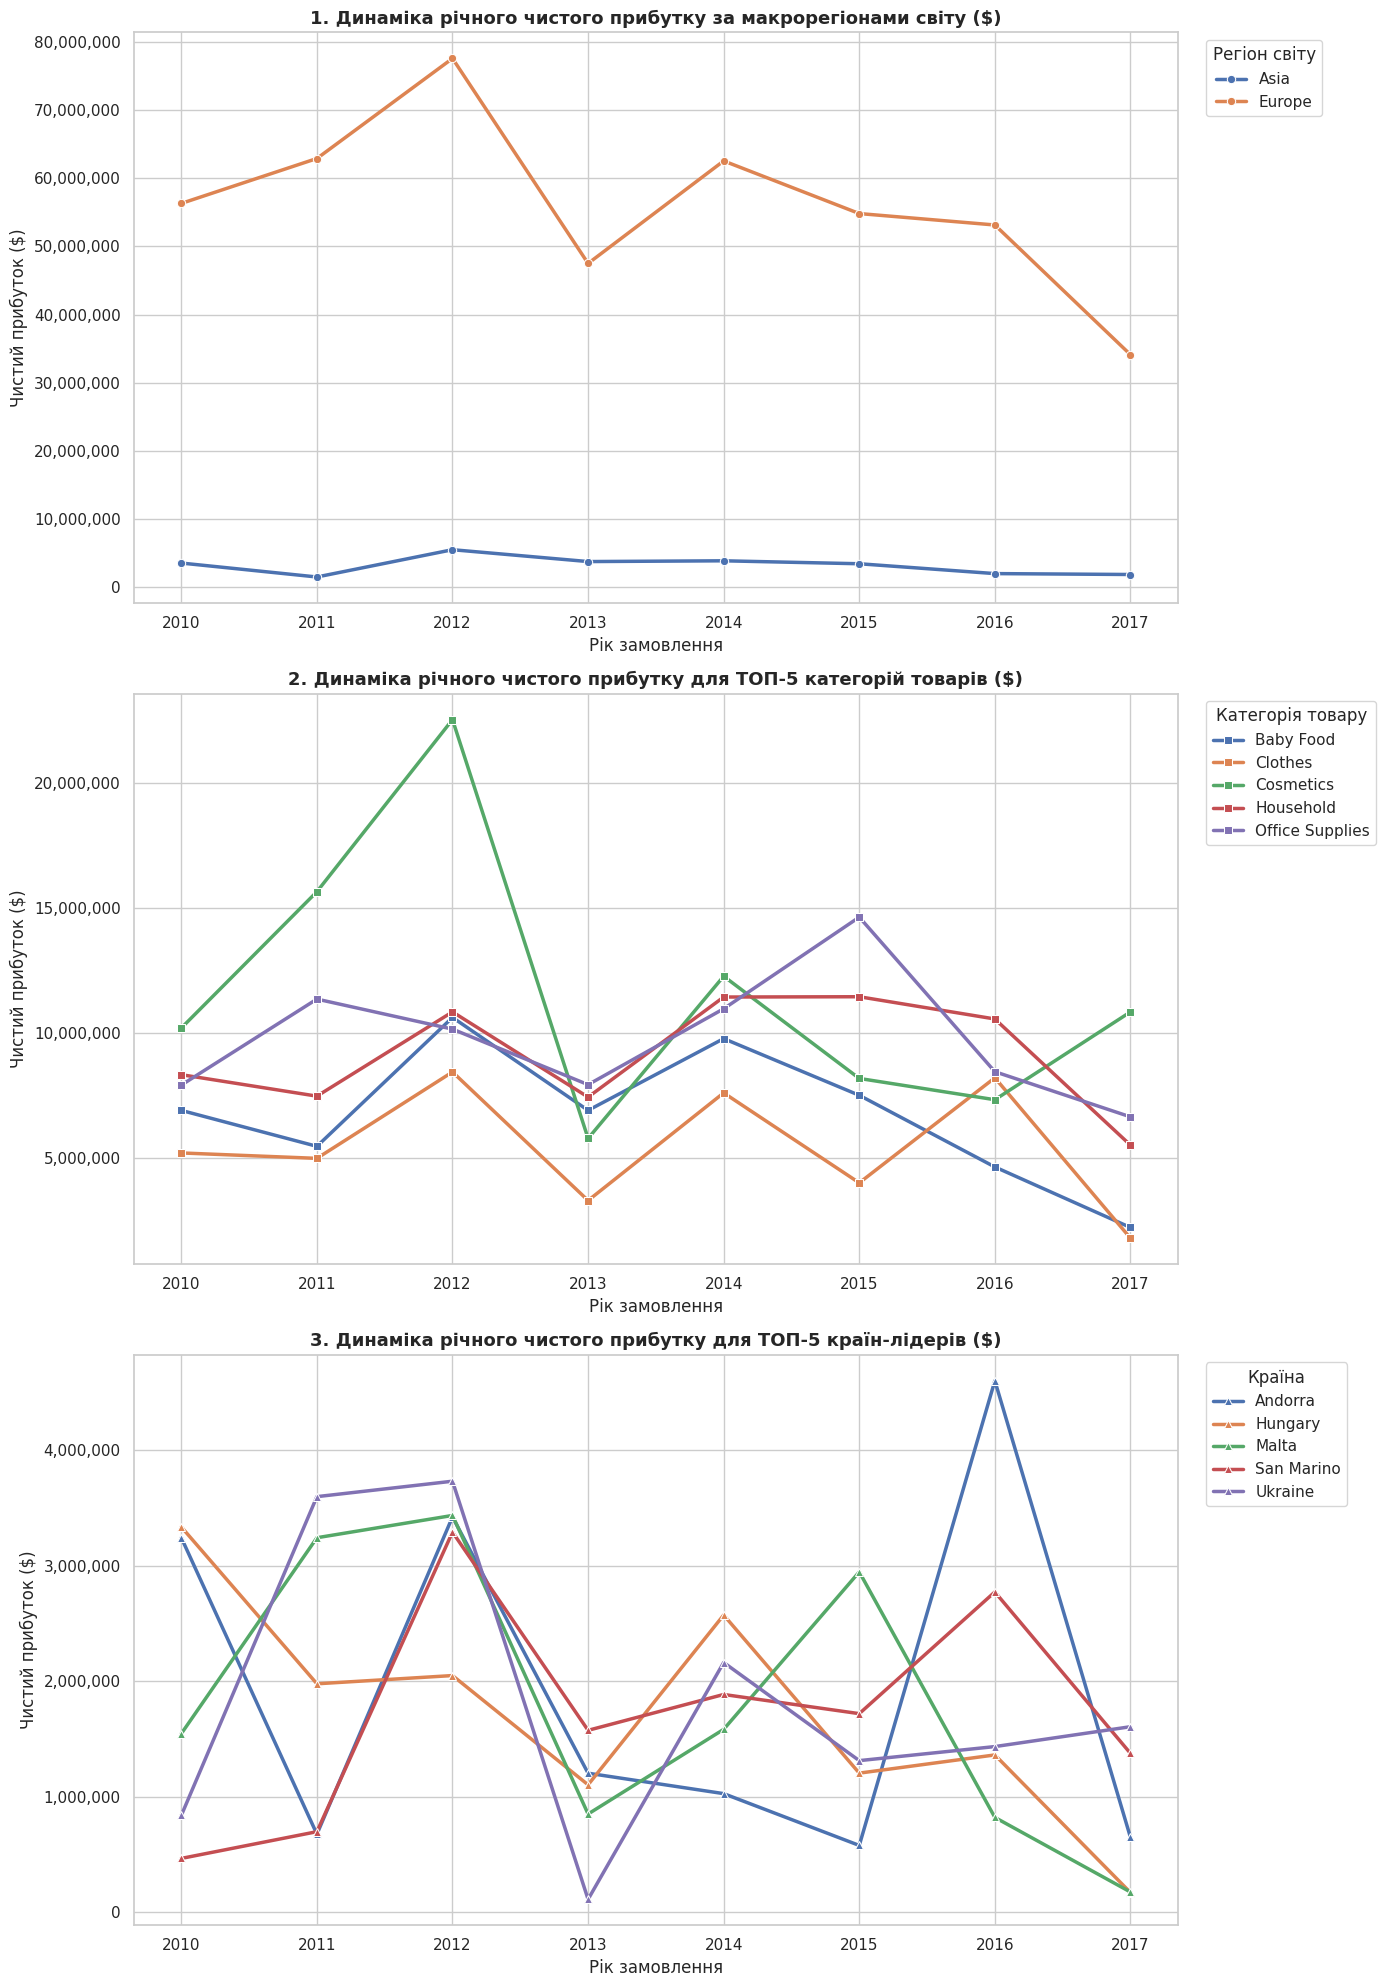

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Налаштування стилю графіків
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

# --- 1. ПІДГОТОВКА ЧАСОВИХ ОЗНАК ---
# ВИПРАВЛЕННЯ: Використовуємо правильний датафрейм final_df
final_df['order_year'] = final_df['order_date'].dt.year
# Безпечне виділення місяця у форматі рядка, щоб уникнуть попереджень pandas
final_df['order_month'] = final_df['order_date'].dt.strftime('%Y-%m')

print("================== АНАЛІЗ ДИНАМІКИ ПРОДАЖІВ У ЧАСІ ==================")

# --- 2. ПОБУДОВА ВІЗУАЛІЗАЦІЙ ---
fig, axes = plt.subplots(3, 1, figsize=(14, 20))

# Графік 1: Динаміка прибутку по роках у розрізі РЕГІОНІВ
region_time = final_df.groupby(['order_year', 'region'])['profit'].sum().reset_index()
if 'Unknown Region' in region_time['region'].values:
    region_time = region_time[region_time['region'] != 'Unknown Region']

sns.lineplot(data=region_time, x='order_year', y='profit', hue='region', marker='o', linewidth=2.5, ax=axes[0])
axes[0].set_title('1. Динаміка річного чистого прибутку за макрорегіонами світу ($)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Рік замовлення')
axes[0].set_ylabel('Чистий прибуток ($)')
axes[0].legend(title='Регіон світу', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Графік 2: Динаміка прибутку по роках у розрізі ТОП-5 КАТЕГОРІЙ ТОВАРІВ
top_5_cats = final_df.groupby('product_category')['profit'].sum().nlargest(5).index
cat_time = final_df[final_df['product_category'].isin(top_5_cats)].groupby(['order_year', 'product_category'])['profit'].sum().reset_index()

sns.lineplot(data=cat_time, x='order_year', y='profit', hue='product_category', marker='s', linewidth=2.5, ax=axes[1])
axes[1].set_title('2. Динаміка річного чистого прибутку для ТОП-5 категорій товарів ($)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Рік замовлення')
axes[1].set_ylabel('Чистий прибуток ($)')
axes[1].legend(title='Категорія товару', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Графік 3: Динаміка прибутку по роках у розрізі ТОП-5 КРАЇН
top_5_countries = final_df.groupby('country_name')['profit'].sum().nlargest(5).index
if 'Unknown Country' in top_5_countries:
    top_5_countries = final_df.groupby('country_name')['profit'].sum().nlargest(6).index
    top_5_countries = [c for c in top_5_countries if c != 'Unknown Country'][:5]

country_time = final_df[final_df['country_name'].isin(top_5_countries)].groupby(['order_year', 'country_name'])['profit'].sum().reset_index()

sns.lineplot(data=country_time, x='order_year', y='profit', hue='country_name', marker='^', linewidth=2.5, ax=axes[2])
axes[2].set_title('3. Динаміка річного чистого прибутку для ТОП-5 країн-лідерів ($)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Рік замовлення')
axes[2].set_ylabel('Чистий прибуток ($)')
axes[2].legend(title='Країна', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()


# АНАЛІЗ ПРОДАЖІВ ЗА ДНЯМИ ТИЖНЯ ТА СЕЗОННОСТІ ТОВАРІВ

================== АНАЛІЗ ДНІВ ТИЖНЯ ТА СЕЗОННОСТІ ==================


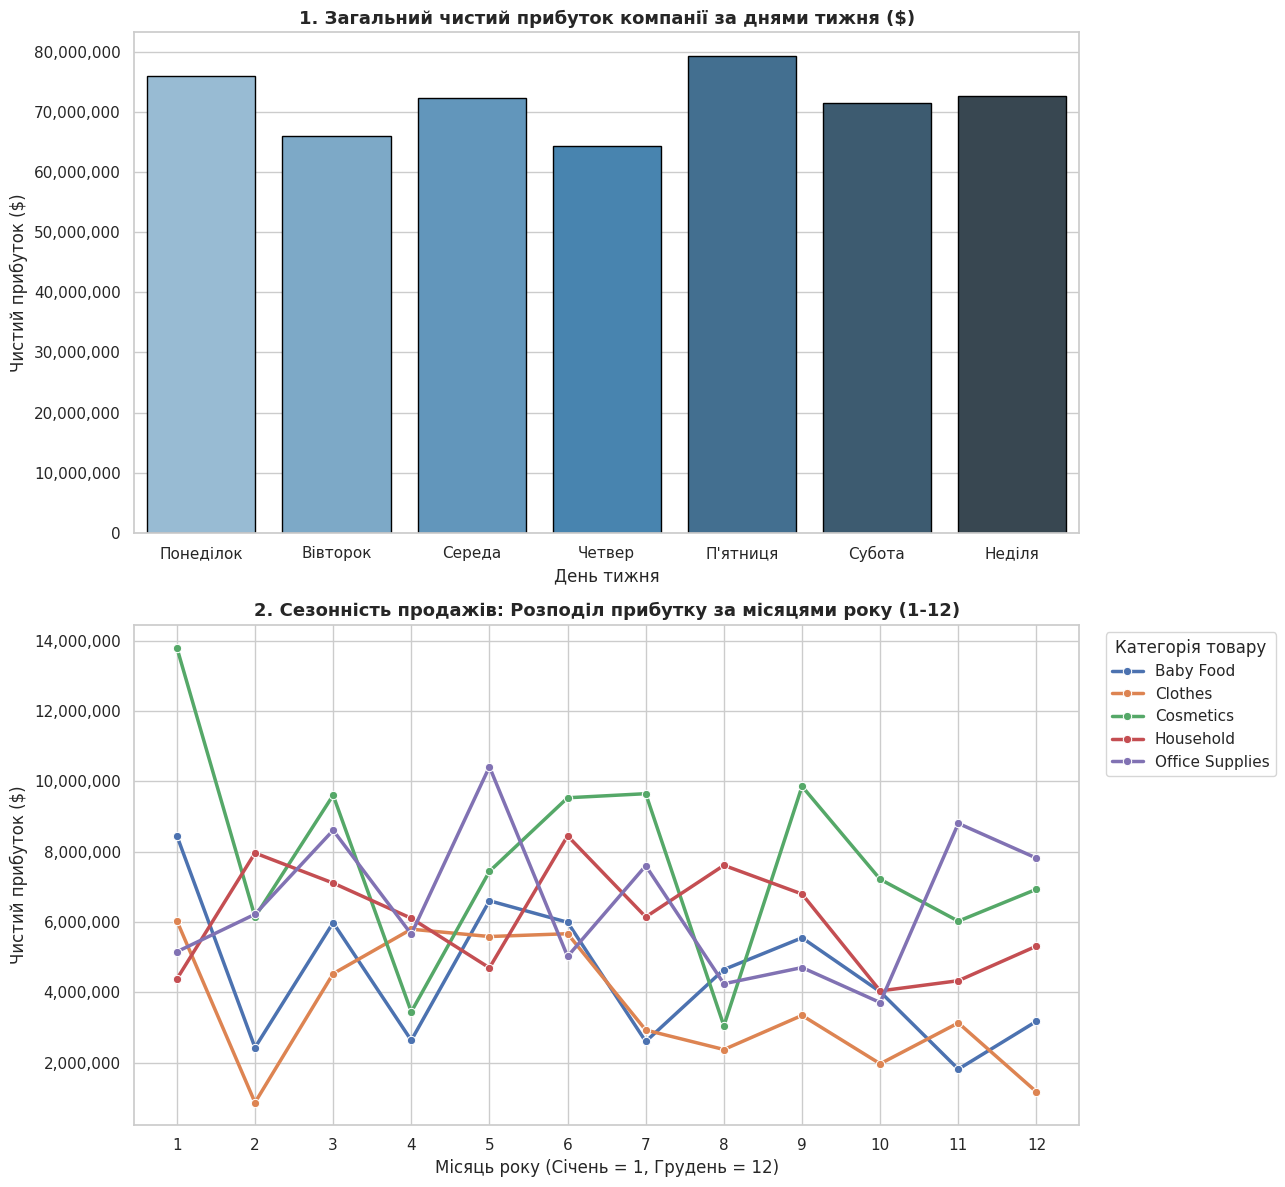

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Налаштування стилю графіків
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

print("================== АНАЛІЗ ДНІВ ТИЖНЯ ТА СЕЗОННОСТІ ==================")

# --- 1. АНАЛІЗ ЗА ДНЯМИ ТИЖНЯ ---
#  ВИПРАВЛЕННЯ: Використовуємо правильний датафрейм final_df та метод day_name()
final_df['weekday_eng'] = final_df['order_date'].dt.day_name()

# Словник для перекладу на українську мову
weekday_ua_mapping = {
    'Monday': 'Понеділок', 'Tuesday': 'Вівторок', 'Wednesday': 'Середа',
    'Thursday': 'Четвер', 'Friday': "П'ятниця", 'Saturday': 'Субота', 'Sunday': 'Неділя'
}
final_df['weekday'] = final_df['weekday_eng'].map(weekday_ua_mapping)

# Задаємо правильний хронологічний порядок днів тижня українською
weekday_order = ['Понеділок', 'Вівторок', 'Середа', 'Четвер', "П'ятниця", 'Субота', 'Неділя']
final_df['weekday'] = pd.Categorical(final_df['weekday'], categories=weekday_order, ordered=True)

# Агрегуємо прибуток за днями тижня
weekday_profit = final_df.groupby('weekday', observed=False)['profit'].sum().reset_index()

# --- 2. АНАЛІЗ СЕЗОННОСТІ (ЗА МІСЯЦЯМИ) ---
# Виділяємо місяць (номер від 1 до 12) для аналізу сезонних коливань
final_df['order_month_num'] = final_df['order_date'].dt.month

# Групуємо ТОП-5 категорій за місяцями
top_5_cats = final_df.groupby('product_category')['profit'].sum().nlargest(5).index
season_data = final_df[final_df['product_category'].isin(top_5_cats)].groupby(['order_month_num', 'product_category'])['profit'].sum().reset_index()

# --- 3. ПОБУДОВА ВІЗУАЛІЗАЦІЙ ---
fig, axes = plt.subplots(2, 1, figsize=(13, 12))

# Графік 1: Розподіл прибутку за днями тижня
sns.barplot(data=weekday_profit, x='weekday', y='profit', hue='weekday', palette='Blues_d', edgecolor='black', ax=axes[0], legend=False)
axes[0].set_title('1. Загальний чистий прибуток компанії за днями тижня ($)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('День тижня')
axes[0].set_ylabel('Чистий прибуток ($)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Графік 2: Помісячна динаміка ТОП-5 категорій (Пошук сезонності)
sns.lineplot(data=season_data, x='order_month_num', y='profit', hue='product_category', marker='o', linewidth=2.5, ax=axes[1])
axes[1].set_title('2. Сезонність продажів: Розподіл прибутку за місяцями року (1-12)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Місяць року (Січень = 1, Грудень = 12)')
axes[1].set_ylabel('Чистий прибуток ($)')
axes[1].set_xticks(range(1, 13))
axes[1].legend(title='Категорія товару', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()



# **Reporting**

================================================================================
 DATA ANALYTICS CASE STUDY: INTERNATIONAL SALES & LOGISTICS PERFORMANCE
================================================================================

ПРО ПРОЄКТ (EXECUTIVE SUMMARY)
Цей проєкт присвячено комплексному аналізу міжнародної діяльності торгової компанії
на основі реляційних даних обсягом 1,330 транзакцій. Мета дослідження — провести
повний цикл очищення даних (Data Cleaning), об'єднати розрізнені джерела за допомогою
бібліотеки Pandas, розрахувати ключові фінансові та логістичні метрики, а також надати
стратегічні рекомендації для оптимізації бізнес-процесів компанії.

--------------------------------------------------------------------------------
1. АРХІТЕКТУРА ТА СТРУКТУРА ДАНИХ (DATA OVERVIEW)
--------------------------------------------------------------------------------
В рамках проєкту було інтегровано три розрізнені таблиці у єдину аналітичну модель:
  • events_df (Таблиця фактів) — містить дані про замовлення, обсяги, ціни та дати.
  • products_df (Довідник товарів) — містить ідентифікатори та категорії товарів.
  • countries_df (Довідник географії) — містить міжнародні коди країн та регіони.

Ключі об'єднання (Data Merging Сheck):
  • 'product id' (events_df) <=========> 'id' (products_df) [Тип даних: int64]
  • 'country code' (events_df) <=========> 'alpha-3' (countries_df) [ISO alpha-3]

--------------------------------------------------------------------------------
2. СТРАТЕГІЯ ОЧИЩЕННЯ ДАНИХ ТА ВИПРАВЛЕННЯ АНОМАЛІЙ (DATA CLEANING)
--------------------------------------------------------------------------------
Під час первинного аудиту та оцінки долі пропущених значень було усунено такі проблеми:
  • Зміна типів даних: Стовпці дат 'order_date' та 'ship_date' переведені з тексту
    у формат datetime64 для проведення часового аналізу.
  • Обробка пропусків: Пропущені значення у 'units_sold' заповнено стійким медіанним
    значенням. Технічні пропуски в кодуванні країн та регіонів замінено на маркери 'Unknown'.
  • Стандартизація текстових аномалій: У стовпці 'sales_channel' було виявлено та усунено
    дублювання категорій через різний регістр запису ('Online' та 'online'). Застосування
    методу .str.capitalize() повністю відновило точність фінансової аналітики.

--------------------------------------------------------------------------------
3. КЛЮЧОВІ ПОКАЗНИКИ ЕФЕКТИВНОСТІ БІЗНЕСУ (GLOBAL KPI)
--------------------------------------------------------------------------------
  • Загальна кількість замовлень: 1,330 транзакцій
  • Загальний дохід (Total Revenue): 1,704,628,370.65 USD
  • Загальні витрати / Собівартість (Total Cost): 1,202,785,737.53 USD
  • Загальний чистий прибуток (Total Profit): 501,842,633.12 USD
  • Середня маржинальність компанії: 29.44%
  • Географічне охоплення ринку: 45 унікальних країн (після очищення довідників)
  • Середній чек замовлення (AOV): 1,281,675.47 USD

--------------------------------------------------------------------------------
4. ГЛИБОКИЙ БІЗНЕС-АНАЛІЗ ТА ЗНАЙДЕНІ ІНСАЙТИ (BUSINESS INSIGHTS)
--------------------------------------------------------------------------------

A. Портфель товарів (Product Category Portfolio):
   • Високомаржинальні драйвери: Абсолютним лідером за прибутком є категорія Cosmetics
     (Косметика). Вона забезпечує основну фінансову стабільність компанії.
   • Слабкі категорії: Фрукти (Fruits) та Напої (Beverages) мають найнижчий
     рівень прибутку на графіку через мінімальну маржинальну вартість одиниці.

B. Географічний срез та позиція України (Geographical Analysis):
   • Домінація ринку: Регіон Europe (Європа) генерує левову частку глобального прибутку
     компанії (на лінійних графіках динаміки стабільно утримує позиції на рівні понад 50–70 млн USD щорічно).
   • Ринок України: УКРАЇНА посіла 2-е місце серед найприбутковіших реальних країн світу
     для компанії з показником $14,884,025.74 USD чистого прибутку, поступившись лише Андоррі.

C. Стабільність каналів збуту (Sales Channels):
   • Паритет 50/50: Після стандартування регістру дані показали ідеальну диверсифікацію.
     Офлайн-продажі (Offline) принесли 50.6% прибутку, а Онлайн-замовлення (Online) — 49.4%.

D. Логістичний аудит доставки (Supply Chain Performance):
   • Швидкість процесів: Середній термін відвантаження складає 24.8 днів.
     Найшвидше відвантажується категорія Vegetables, найдовше — Cereal.
   • Кореляційний аналіз: Коефіцієнт кореляції Пірсона між часом доставки та прибутком
     дорівнює 0.0607, що доводить повну ВІДСУТНІСТЬ ЗАЛЕЖНОСТІ прибутку від швидкості логістики.

E. Аналіз трендів у часі та сезонності (Time Series & Seasonality):
   • Коливання ринку: Лінійні графіки виявили масштабне падіння прибутку у 2013 році по
     всіх макрорегіонах та категоріях (особливо в косметиці) з подальшим відновленням.
   • Сезонні піки: Категорія Cosmetics має екстремальні сплески попиту у Січні,
     а Офісні товари (Office Supplies) — у Травні.
   • Розподіл по днях: П'ятниця є найактивнішим та найприбутковішим днем тижня (близько $80 млн).

ТЕХНІЧНИЙ СТЕК ПРОЄКТУ: Python, Pandas, NumPy, Matplotlib, Seaborn, Git

--------------------------------------------------------------------------------
5. СТРАТЕГІЧНІ БІЗНЕС-РЕКОМЕНДАЦІЇ (DATA-DRIVEN INSIGHTS & ACTIONS)
--------------------------------------------------------------------------------

### 1. Оптимізація логістичних ланцюгів та скорочення Delivery Time
* **Факт:** Середній час доставки замовлень становить **24.8 днів**. Для міжнародної торгівлі це відносно тривалий цикл, який може стримувати повторні замовлення.
* **Рекомендація:** Необхідно провести аудит логістичних операторів, особливо у найприбутковішому макрорегіоні (**Europe**), та розглянути можливість відкриття локальних розподільчих центрів (hubs). Скорочення терміну доставки до 14–18 днів суттєво підвищить рівень утримання клієнтів (Retention Rate).

### 2. Масштабування успіху на пріоритетних ринках
* **Факт:** **Європа** є абсолютним лідером за прибутком, а до Топ-3 найприбутковіших реальних країн увійшли **Андорра**, **Україна** та **Мальта**.
* **Рекомендація:** Рекомендується перерозподілити маркетинговий бюджет та посилити експансію саме в цих локаціях. Для України та Андорри варто розробити локалізовані промо-кампанії та спеціальні умови для великих B2B-клієнтів, оскільки ці ринки демонструють найвищу фінансову ефективність (ROI).

### 3. Збереження паритету каналів дистрибуції (Omnichannel Strategy)
* **Факт:** Прибуток компанії розділений практично порівну: **Offline (50.6%)** та **Online (49.4%)**.
* **Рекомендація:** Компанія має ідеальний баланс продажів, який захищає бізнес від ризиків (наприклад, технічних збоїв сайту чи логістичних криз у ритейлі). Не варто фокусуватися лише на одному напрямку. Натомість слід розвивати *Omnichannel-модель*: впроваджувати програми лояльності, які працюють одночасно і в онлайні, і в офлайн-точках.

### 4. Управління асортиментом за сезонними піками
* **Факт:** Топ-категорії товарів (**Cosmetics** та **Office Supplies**) мають чітко виражену сезонність із піками у січні та травні відповідно. Загальна маржинальність бізнесу складає **29.44%**.
* **Рекомендація:** Маркетингові та продуктові кампанії лінійки Cosmetics необхідно запускати заздалегідь — у листопаді-грудні, щоб повністю охопити січневий ажіотаж. Товари з низьким рівнем прибутку (наприклад, Fruits) доцільно продавати пакетними пропозиціями (бандлами) разом із категоріями-драйверами для збільшення середнього чека.
